# *American Sign Language Recognition*

---

## *Table of Contents*
---
1. Introduction
2. Data
3. Code
* 3.1 Import Packages
* 3.2 Data Loading and Checking
    * 3.2.1 Data Loading
    * 3.2.2 Image Dimensions
* 3.3 Class Check
* 3.4 Data Splitting
* 3.5 Model Architecture
* 3.6 Training and Evaluation Function
* 3.7 Experiments with Data Augmentation
* 3.8 Experiments without Data Augmentation
* 3.9 Performance Comparison
4. Best Model
* 4.1 Training Curves
    * 4.1.1 Training and Validation Accuracy
    * 4.1.2 Training and Validation Loss
* 4.2 Confusion Matrix
---

## ***1. Introduction***

---

##### Sign language is one of the primary means of communication for people with hearing or speech impairments. Among the different sign languages, American Sign Language (ASL) is one of the most widely used, serving hundreds of thousands of individuals across the United States and parts of Canada. Despite its widespread use, communication between ASL users and people unfamiliar with sign language remains a significant challenge in everyday life.

##### Recent advances in Artificial Intelligence, Computer Vision, and Deep Learning have enabled the development of automated sign language recognition systems capable of translating hand gestures into meaningful information. Such systems can contribute to more accessible communication and improve the interaction between deaf or hard-of-hearing individuals and the general population.

##### The objective of this project is to develop a Convolutional Neural Network (CNN) capable of recognizing American Sign Language hand gestures from RGB images. Multiple experimental configurations are evaluated by comparing different batch sizes both with and without data augmentation. The models are assessed using several classification metrics in order to identify the best-performing architecture.

## ***2. Data***
---
##### The dataset used in this project consists of RGB images representing 27 American Sign Language classes. Each image has a spatial resolution of 128 × 128 pixels and three color channels. The dataset is used to train and evaluate a convolutional neural network for multi-class image classification.
#### ***Data***
> * ##### The data obtained was from 173 volunteers.
* ##### A large number of users is defined as [1].
* ##### Selected numbers: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9.
* ##### Selected letters: A, B, C, D, E.
* ##### Selected expressions: Hello, Yes, No, Good, Bye, Good morning, Whats up, Pardon, Project, Little bit, Please.
* ##### NULL class, which contains 314 random photos, without any sign language gestures and is the 27th class of the dataset.

#### ***Images***
> * ##### Right-handed gesture.
* ##### Camera: 3024pixels x 3024pixels.
* ##### Color space: RGB.
* ##### Total images: 130 from each individual, 5 from each class.
* ##### Total images: 22,801
* ##### Shots from different angles with minor changes.
* ##### Variety of images in background and light.

#### ***Data Processing***
> * ##### Resize to 128 pixels x 128 pixels.
* ##### Integer values ​​in the range [0, 255] and normalize to 32-bit float in the range [0, 1].

#### ***Data Storage***
> * ##### Store processed images in NumPy Tensor "X" 4D (number of photos, height, width and three RGB color channels)
* ##### Store label in NumPy Tensor "Y" 2D (image number, label)

## ***3. Code***
---

### ***3.1 Import Packages***

---

##### The required Python libraries are imported to support data manipulation, visualization, deep learning, and model evaluation. TensorFlow and Keras are used for constructing and training the convolutional neural network, while NumPy, Pandas, Matplotlib, and Scikit-learn provide utilities for preprocessing, performance evaluation, and visualization.

In [1]:
%pip install --upgrade pip
%pip install --upgrade numpy
%pip install --upgrade scipy
%pip install --upgrade scikit-learn
%pip install --upgrade matplotlib
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/marina/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/marina/Library/Python/3.10/lib/python/site-packages/traitlets/config/ap

### ***3.2 Data Loading and Checking***

---

##### The ASL dataset is loaded into memory and inspected before training. This step verifies that both the image and label arrays have been successfully imported and ensures that the dataset is suitable for the subsequent preprocessing and training stages.

##### ***3.2.1 Data Loading***

---

##### The image dataset **X.npy** and the corresponding class labels **Y.npy** are loaded into the Python environment. These arrays constitute the input features and target labels used throughout the classification workflow.

In [3]:
x_data = np.load('X.npy') # Images
y_data = np.load('Y.npy') # Labels

print("x_data: ", x_data.shape) # Images
print("y_data: ", y_data.shape) # Labels

x_data:  (22801, 128, 128, 3)
y_data:  (22801, 1)


##### ***3.2.2 Image Dimensions***

---

##### Each sample in the dataset consists of an RGB image with a resolution of **128 × 128 pixels**. The dataset contains **22,801 images**, each represented by three color channels corresponding to the RGB color space. Verifying the image dimensions ensures that all samples have a consistent format before training the convolutional neural network.

In [4]:
height, width, channels = x_data.shape[-3:]
print("The size of image is: ", height, width, channels)

The size of image is:  128 128 3


##### The size of x_data indicates the total number of images (22,801), together with their spatial dimensions (128 × 128 pixels) and the three RGB color channels.

##### The size of y_data confirms that each image is associated with one corresponding class label, resulting in a total of 22,801 labels.

### ***3.3 Class Check***

---

##### The available class labels are identified and examined before training the neural network. Each unique class is mapped to a numerical identifier, allowing the categorical labels to be converted into a format that can be processed by deep learning algorithms.

In [5]:
classes = np.unique(y_data)
print("classes: ", classes)
print ("Number of classes", len(classes))

classes:  ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']
Number of classes 27


In [6]:
label_map = {label: i for i, label in enumerate(classes)}
print("label map: ", label_map)

label map:  {np.str_('0'): 0, np.str_('1'): 1, np.str_('2'): 2, np.str_('3'): 3, np.str_('4'): 4, np.str_('5'): 5, np.str_('6'): 6, np.str_('7'): 7, np.str_('8'): 8, np.str_('9'): 9, np.str_('NULL'): 10, np.str_('a'): 11, np.str_('b'): 12, np.str_('bye'): 13, np.str_('c'): 14, np.str_('d'): 15, np.str_('e'): 16, np.str_('good'): 17, np.str_('good morning'): 18, np.str_('hello'): 19, np.str_('little bit'): 20, np.str_('no'): 21, np.str_('pardon'): 22, np.str_('please'): 23, np.str_('project'): 24, np.str_('whats up'): 25, np.str_('yes'): 26}


In [7]:
y_int = np.array([label_map[label] for label in y_data.flatten()])
y_cat = to_categorical(y_int, num_classes=len(label_map)).astype(int)

### ***3.4 Data Splitting***

---

##### Before training, the images are converted to floating-point values and normalized whenever necessary. The complete dataset is then divided into **70% training data** and **30% testing data** using stratified sampling, ensuring that the original class distribution is preserved across both subsets while maintaining reproducibility through a fixed random state.

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data, 
    y_cat, 
    test_size = 0.3, 
    random_state = 42,
    stratify = y_int
    )

In [9]:
print("x_train shape is:", x_train.shape) # Train set images
print("y_train shape is:", y_train.shape) # Train set labels
print("x_test shape is:", x_test.shape) # Test set images
print("y_test shape is:", y_test.shape) # Test set labels

x_train shape is: (15960, 128, 128, 3)
y_train shape is: (15960, 27)
x_test shape is: (6841, 128, 128, 3)
y_test shape is: (6841, 27)


### ***3.5 Model Architecture***

In [17]:
def build_cnn_model(use_augmentation=False):
    layers = []

    if use_augmentation:
        layers.append(
            keras.Sequential([
                keras.layers.RandomFlip("horizontal")
            ], name="data_augmentation")
        )

    layers.extend([
        Conv2D(32, (3, 3), activation='relu', input_shape=x_data.shape[1:]),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(len(classes), activation='softmax')
    ])

    model = keras.Sequential(layers)

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### ***3.6 Training and Evaluation Function***

In [18]:
def train_and_evaluate_model(experiment_name, batch_size, use_augmentation=False, epochs=30):
    print(f"Running experiment: {experiment_name}")
    
    keras.backend.clear_session()
    gc.collect()

    model = build_cnn_model(use_augmentation=use_augmentation)
    print("Model created successfully.")
    print("Starting training.")
    
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=2
    )
    
    print("Training completed.")
    print("Starting evaluation...")

    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    os.makedirs("models", exist_ok=True)

    model_path = f"models/{experiment_name}.h5"
    model.save(model_path)

    print("Evaluation completed.")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Saved to : {model_path}")
    print("=" * 70)

    results = {
        "experiment": experiment_name,
        "batch_size": batch_size,
        "augmentation": use_augmentation,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "model": model,
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred
    }
    
    return results

### ***3.7 Experiments with Data Augmentation***

In [19]:
experiments = [
    {
        "name": "augmentation_batch_16",
        "batch_size": 16,
        "use_augmentation": True,
        "epochs": 30
    },
    {
        "name": "augmentation_batch_32",
        "batch_size": 32,
        "use_augmentation": True,
        "epochs": 30
    },
    {
        "name": "augmentation_batch_64",
        "batch_size": 64,
        "use_augmentation": True,
        "epochs": 30
    }
]

In [20]:
experiment_results = []

for exp in experiments:
    result = train_and_evaluate_model(
        experiment_name=exp["name"],
        batch_size=exp["batch_size"],
        use_augmentation=exp["use_augmentation"],
        epochs=exp["epochs"]
    )
    
    experiment_results.append(result)

Running experiment: augmentation_batch_16


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model created successfully.
Starting training.
Epoch 1/30
998/998 - 214s - 215ms/step - accuracy: 0.3326 - loss: 2.2194 - val_accuracy: 0.6135 - val_loss: 1.2542
Epoch 2/30
998/998 - 194s - 195ms/step - accuracy: 0.6643 - loss: 1.0663 - val_accuracy: 0.7478 - val_loss: 0.8292
Epoch 3/30
998/998 - 191s - 191ms/step - accuracy: 0.7710 - loss: 0.7231 - val_accuracy: 0.7834 - val_loss: 0.6929
Epoch 4/30
998/998 - 190s - 191ms/step - accuracy: 0.8345 - loss: 0.5367 - val_accuracy: 0.8135 - val_loss: 0.6003
Epoch 5/30
998/998 - 190s - 191ms/step - accuracy: 0.8682 - loss: 0.4104 - val_accuracy: 0.8277 - val_loss: 0.5521
Epoch 6/30
998/998 - 189s - 189ms/step - accuracy: 0.8950 - loss: 0.3366 - val_accuracy: 0.8348 - val_loss: 0.5390
Epoch 7/30
998/998 - 189s - 190ms/step - accuracy: 0.9179 - loss: 0.2597 - val_accuracy: 0.8531 - val_loss: 0.4850
Epoch 8/30
998/998 - 189s - 189ms/step - accuracy: 0.9298 - loss: 0.2226 - val_accuracy: 0.8728 - val_loss: 0.4349
Epoch 9/30
998/998 - 189s - 189ms

Evaluation completed.
Accuracy : 0.9010
Precision: 0.9043
Recall   : 0.9010
F1 Score : 0.9014
Saved to : models/augmentation_batch_16.h5
Running experiment: augmentation_batch_32


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model created successfully.
Starting training.
Epoch 1/30
499/499 - 187s - 374ms/step - accuracy: 0.2299 - loss: 2.5875 - val_accuracy: 0.5376 - val_loss: 1.4878
Epoch 2/30
499/499 - 197s - 394ms/step - accuracy: 0.6337 - loss: 1.1740 - val_accuracy: 0.7348 - val_loss: 0.8512
Epoch 3/30
499/499 - 198s - 396ms/step - accuracy: 0.7780 - loss: 0.7115 - val_accuracy: 0.7762 - val_loss: 0.7197
Epoch 4/30
499/499 - 187s - 376ms/step - accuracy: 0.8400 - loss: 0.5096 - val_accuracy: 0.8360 - val_loss: 0.5380
Epoch 5/30
499/499 - 200s - 401ms/step - accuracy: 0.8813 - loss: 0.3791 - val_accuracy: 0.8307 - val_loss: 0.5675
Epoch 6/30
499/499 - 204s - 408ms/step - accuracy: 0.9069 - loss: 0.3036 - val_accuracy: 0.8332 - val_loss: 0.5416
Epoch 7/30
499/499 - 203s - 406ms/step - accuracy: 0.9261 - loss: 0.2378 - val_accuracy: 0.8721 - val_loss: 0.4107
Epoch 8/30
499/499 - 193s - 386ms/step - accuracy: 0.9333 - loss: 0.2112 - val_accuracy: 0.8442 - val_loss: 0.5065
Epoch 9/30
499/499 - 197s - 395ms

Evaluation completed.
Accuracy : 0.8829
Precision: 0.8892
Recall   : 0.8829
F1 Score : 0.8825
Saved to : models/augmentation_batch_32.h5
Running experiment: augmentation_batch_64
Model created successfully.
Starting training.


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
250/250 - 200s - 800ms/step - accuracy: 0.1595 - loss: 2.8784 - val_accuracy: 0.3709 - val_loss: 2.0587
Epoch 2/30
250/250 - 187s - 748ms/step - accuracy: 0.5843 - loss: 1.3502 - val_accuracy: 0.7084 - val_loss: 0.9195
Epoch 3/30
250/250 - 193s - 773ms/step - accuracy: 0.7731 - loss: 0.7259 - val_accuracy: 0.7839 - val_loss: 0.6646
Epoch 4/30
250/250 - 186s - 745ms/step - accuracy: 0.8540 - loss: 0.4627 - val_accuracy: 0.8249 - val_loss: 0.5529
Epoch 5/30
250/250 - 190s - 760ms/step - accuracy: 0.9027 - loss: 0.3215 - val_accuracy: 0.8785 - val_loss: 0.3967
Epoch 6/30
250/250 - 188s - 751ms/step - accuracy: 0.9311 - loss: 0.2188 - val_accuracy: 0.8766 - val_loss: 0.4140
Epoch 7/30
250/250 - 187s - 750ms/step - accuracy: 0.9491 - loss: 0.1653 - val_accuracy: 0.8787 - val_loss: 0.4409
Epoch 8/30
250/250 - 182s - 727ms/step - accuracy: 0.9602 - loss: 0.1326 - val_accuracy: 0.8883 - val_loss: 0.3723
Epoch 9/30
250/250 - 189s - 754ms/step - accuracy: 0.9689 - loss: 0.0987 - val_a

Evaluation completed.
Accuracy : 0.8930
Precision: 0.8998
Recall   : 0.8930
F1 Score : 0.8926
Saved to : models/augmentation_batch_64.h5


### ***3.8 Experiments without Data Augmentation***

In [23]:
no_augmentation_experiments = [
    {
        "experiment_name": "asl_noaug_bs16",
        "batch_size": 16,
        "use_augmentation": False,
        "epochs": 30
    },
    {
        "experiment_name": "asl_noaug_bs32",
        "batch_size": 32,
        "use_augmentation": False,
        "epochs": 30
    },
    {
        "experiment_name": "asl_noaug_bs64",
        "batch_size": 64,
        "use_augmentation": False,
        "epochs": 30
    }
]

In [24]:
no_augmentation_results = []

for exp in no_augmentation_experiments:
    no_augmentation_results.append(
        train_and_evaluate_model(**exp)
    )

Running experiment: asl_noaug_bs16
Model created successfully.
Starting training.


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
998/998 - 111s - 111ms/step - accuracy: 0.3351 - loss: 2.2519 - val_accuracy: 0.7148 - val_loss: 0.9171
Epoch 2/30
998/998 - 101s - 101ms/step - accuracy: 0.7998 - loss: 0.6663 - val_accuracy: 0.8474 - val_loss: 0.4918
Epoch 3/30
998/998 - 100s - 100ms/step - accuracy: 0.8940 - loss: 0.3382 - val_accuracy: 0.8855 - val_loss: 0.3807
Epoch 4/30
998/998 - 101s - 101ms/step - accuracy: 0.9372 - loss: 0.1994 - val_accuracy: 0.9032 - val_loss: 0.3290
Epoch 5/30
998/998 - 102s - 102ms/step - accuracy: 0.9549 - loss: 0.1447 - val_accuracy: 0.8891 - val_loss: 0.3854
Epoch 6/30
998/998 - 102s - 102ms/step - accuracy: 0.9674 - loss: 0.1022 - val_accuracy: 0.9003 - val_loss: 0.3754
Epoch 7/30
998/998 - 106s - 106ms/step - accuracy: 0.9721 - loss: 0.0888 - val_accuracy: 0.9040 - val_loss: 0.3815
Epoch 8/30
998/998 - 105s - 105ms/step - accuracy: 0.9725 - loss: 0.0865 - val_accuracy: 0.9038 - val_loss: 0.4239
Epoch 9/30
998/998 - 106s - 106ms/step - accuracy: 0.9793 - loss: 0.0696 - val_a

Evaluation completed.
Accuracy : 0.9257
Precision: 0.9261
Recall   : 0.9257
F1 Score : 0.9254
Saved to : models/asl_noaug_bs16.h5
Running experiment: asl_noaug_bs32


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model created successfully.
Starting training.
Epoch 1/30
499/499 - 202s - 404ms/step - accuracy: 0.2154 - loss: 2.6899 - val_accuracy: 0.5545 - val_loss: 1.4443
Epoch 2/30
499/499 - 194s - 388ms/step - accuracy: 0.7093 - loss: 0.9461 - val_accuracy: 0.7986 - val_loss: 0.6606
Epoch 3/30
499/499 - 201s - 402ms/step - accuracy: 0.8663 - loss: 0.4401 - val_accuracy: 0.8613 - val_loss: 0.4492
Epoch 4/30
499/499 - 191s - 383ms/step - accuracy: 0.9242 - loss: 0.2431 - val_accuracy: 0.8680 - val_loss: 0.4475
Epoch 5/30
499/499 - 213s - 426ms/step - accuracy: 0.9536 - loss: 0.1499 - val_accuracy: 0.8793 - val_loss: 0.4371
Epoch 6/30
499/499 - 254s - 509ms/step - accuracy: 0.9686 - loss: 0.0940 - val_accuracy: 0.8892 - val_loss: 0.4289
Epoch 7/30
499/499 - 206s - 412ms/step - accuracy: 0.9801 - loss: 0.0644 - val_accuracy: 0.9089 - val_loss: 0.3884
Epoch 8/30
499/499 - 197s - 394ms/step - accuracy: 0.9734 - loss: 0.0789 - val_accuracy: 0.8896 - val_loss: 0.4542
Epoch 9/30
499/499 - 198s - 396ms

Evaluation completed.
Accuracy : 0.9138
Precision: 0.9156
Recall   : 0.9138
F1 Score : 0.9136
Saved to : models/asl_noaug_bs32.h5
Running experiment: asl_noaug_bs64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model created successfully.
Starting training.
Epoch 1/30
250/250 - 211s - 842ms/step - accuracy: 0.2620 - loss: 2.5384 - val_accuracy: 0.5999 - val_loss: 1.3007
Epoch 2/30
250/250 - 196s - 786ms/step - accuracy: 0.7199 - loss: 0.9224 - val_accuracy: 0.8049 - val_loss: 0.6407
Epoch 3/30
250/250 - 198s - 790ms/step - accuracy: 0.8657 - loss: 0.4428 - val_accuracy: 0.8557 - val_loss: 0.4714
Epoch 4/30
250/250 - 195s - 781ms/step - accuracy: 0.9271 - loss: 0.2415 - val_accuracy: 0.8629 - val_loss: 0.4876
Epoch 5/30
250/250 - 196s - 782ms/step - accuracy: 0.9594 - loss: 0.1366 - val_accuracy: 0.8803 - val_loss: 0.4100
Epoch 6/30
250/250 - 195s - 779ms/step - accuracy: 0.9754 - loss: 0.0801 - val_accuracy: 0.8731 - val_loss: 0.5228
Epoch 7/30
250/250 - 195s - 778ms/step - accuracy: 0.9821 - loss: 0.0571 - val_accuracy: 0.8949 - val_loss: 0.4366
Epoch 8/30
250/250 - 197s - 788ms/step - accuracy: 0.9845 - loss: 0.0505 - val_accuracy: 0.8869 - val_loss: 0.4541
Epoch 9/30
250/250 - 196s - 783ms

Evaluation completed.
Accuracy : 0.9181
Precision: 0.9199
Recall   : 0.9181
F1 Score : 0.9176
Saved to : models/asl_noaug_bs64.h5


### ***3.9 Performance Comparison***

In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [50]:
saved_models = [
    {"experiment": "augmentation_batch_16", "batch_size": 16, "augmentation": True,  "model_path": "models/augmentation_batch_16.h5"},
    {"experiment": "augmentation_batch_32", "batch_size": 32, "augmentation": True,  "model_path": "models/augmentation_batch_32.h5"},
    {"experiment": "augmentation_batch_64", "batch_size": 64, "augmentation": True,  "model_path": "models/augmentation_batch_64.h5"},
    {"experiment": "asl_noaug_bs16",        "batch_size": 16, "augmentation": False, "model_path": "models/asl_noaug_bs16.h5"},
    {"experiment": "asl_noaug_bs32",        "batch_size": 32, "augmentation": False, "model_path": "models/asl_noaug_bs32.h5"},
    {"experiment": "asl_noaug_bs64",        "batch_size": 64, "augmentation": False, "model_path": "models/asl_noaug_bs64.h5"}
]

In [87]:
all_results = experiment_results + no_augmentation_results

comparison = pd.DataFrame([
    {
        "Experiment": r["experiment"],
        "Batch Size": r["batch_size"],
        "Data Augmentation": "Yes" if r["augmentation"] else "No",
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1 Score": r["f1_score"]
    }
    for r in all_results
])

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Experiment,Batch Size,Data Augmentation,Accuracy,Precision,Recall,F1 Score
0,asl_noaug_bs16,16,No,0.9257,0.9261,0.9257,0.9254
1,asl_noaug_bs64,64,No,0.9181,0.9199,0.9181,0.9176
2,asl_noaug_bs32,32,No,0.9138,0.9156,0.9138,0.9136


In [88]:
comparison.to_csv("results/experiment_comparison.csv", index=False)
print("Experiment comparison saved successfully.")

Experiment comparison saved successfully.


### ***4. Best Model***

In [90]:
best_model = max(
    all_results,
    key=lambda x: x["accuracy"]
)

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Experiment        : {best_model['experiment']}")
print(f"Batch Size        : {best_model['batch_size']}")
print(f"Data Augmentation : {'Yes' if best_model['augmentation'] else 'No'}")
print(f"Accuracy          : {best_model['accuracy']:.4f}")
print(f"Precision         : {best_model['precision']:.4f}")
print(f"Recall            : {best_model['recall']:.4f}")
print(f"F1 Score          : {best_model['f1_score']:.4f}")

print("=" * 70)

best_model["model"].summary()

BEST MODEL
Experiment        : asl_noaug_bs16
Batch Size        : 16
Data Augmentation : No
Accuracy          : 0.9257
Precision         : 0.9261
Recall            : 0.9257
F1 Score          : 0.9254


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,715,027 (17.99 MB)

 Trainable params: 1,571,675 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,143,352 (11.99 MB)

### ***4.1 Training Curves for Best Model***

#### ***4.1.1 Training and Validation Accuracy***

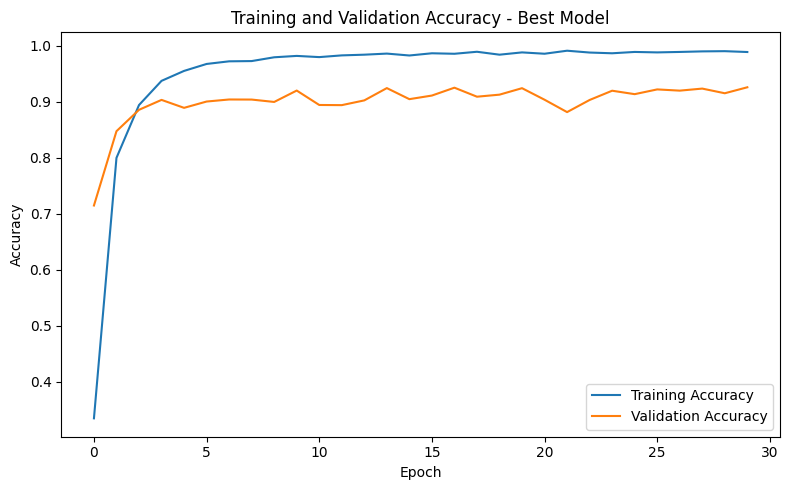

In [91]:
history = best_model["history"]

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - Best Model")
plt.legend()
plt.tight_layout()
plt.savefig("results/best_model_accuracy.png", dpi=300)
plt.show()

#### ***4.1.2 Training and Validation Loss***

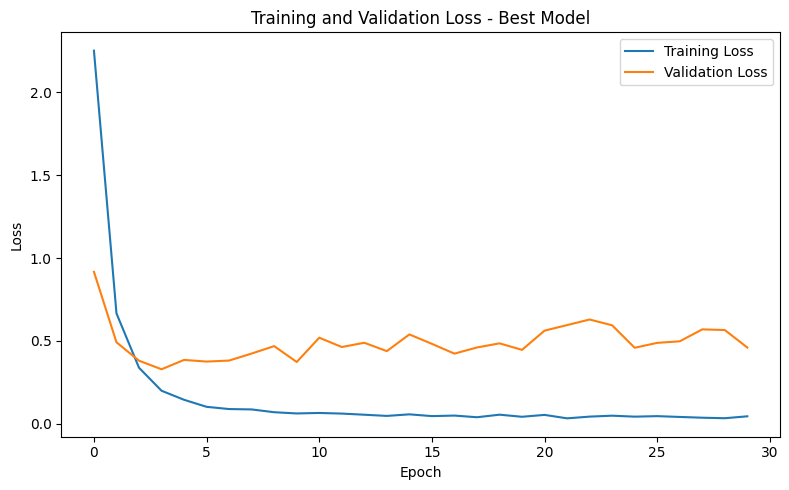

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - Best Model")
plt.legend()
plt.tight_layout()
plt.savefig("results/best_model_loss.png", dpi=300)
plt.show()

### ***4.2 Confusion Matrix***

<Figure size 1200x1000 with 0 Axes>

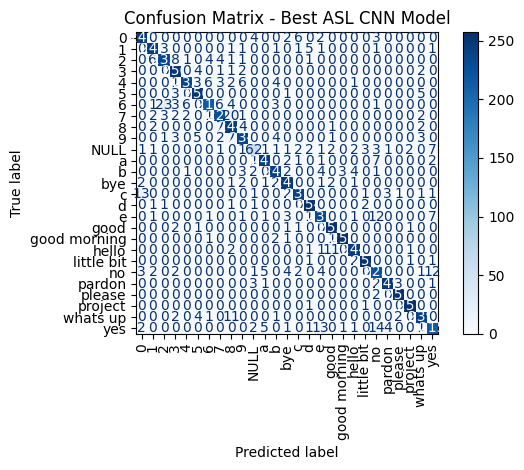

In [93]:
cm = confusion_matrix(
    best_model["y_true"],
    best_model["y_pred"]
)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Best ASL CNN Model")
plt.tight_layout()
plt.savefig("results/best_model_confusion_matrix.png", dpi=300)
plt.show()